# Camera calibration with a Charuco board in MuJoCo

This notebook demonstrates a complete camera-calibration workflow using a simulated camera, a robot, and a Charuco calibration board.

The workflow has two main stages:

- **Intrinsic calibration** estimates the camera matrix and distortion parameters from multiple board images.
- **Extrinsic calibration** estimates the camera pose with respect to the robot base.

Although the example runs in MuJoCo, the calibration logic is the same for a real setup: collect informative board views, detect the board reliably, save synchronized robot and image data, and solve the calibration problem from those measurements.


## Imports


In [ ]:
import numpy as np
import cv2
import glob
import os

import mediapy as media
import matplotlib.pyplot as plt

from IPython.display import clear_output
clear_output()

import mujoco
from robotblockset.mujoco.robots_pymujoco import mujoco_scene, panda
from robotblockset.transformations import rot_z, map_pose, t2x, x2t, frame2world, world2frame, uniqueCartesianPath, xerr
from robotblockset.tools import get_rbs_path
from robotblockset.graphics import display_images

from robotblockset.cameras.collect_calibration_data import create_data_dir, prepare_collect_calibration_data

from robotblockset.cameras.calibration_boards import CharucoBoard
from robotblockset.cameras.camera_calibration import detect_aruco_markers, detect_charuco_corners, detect_and_visualize_charuco_pose
from robotblockset.cameras.camera_calibration import get_pose_of_charuco_board
from robotblockset.cameras.camera_calibration import BoardDetectionResults, load_images, save_images
from robotblockset.cameras.camera_calibration import load_calibration_data
from robotblockset.cameras.camera_calibration import extrinsic_calibration_all_methods
from robotblockset.cameras.image_converter import ImageConverter

from robotblockset.cameras.mujoco_camera import MujocoCam

np.set_printoptions(precision=3, suppress=True, linewidth=100)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Helper functions for the MuJoCo example

These helper functions save and load robot joint states, Cartesian poses, images, and camera intrinsics using the file structure expected by the calibration routines.


In [2]:
import json
from robotblockset.cameras.camera_calibration import CameraIntrinsics, save_pose_to_json, load_pose_from_json

import numpy as np
from pathlib import Path


def save_q_to_json(q: np.ndarray, path: str | Path):
    """
    Save robot joint vector q (1D numpy array) to a JSON file.
    """
    q = np.asarray(q, dtype=float).reshape(-1)

    data = {
        "q": q.tolist(),
        "n_joints": int(q.size),
    }

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_q_from_json(path: str | Path) -> np.ndarray:
    """
    Load robot joint vector q from a JSON file and return it as a numpy array.
    """
    path = Path(path)
    data = json.loads(path.read_text(encoding="utf-8"))

    if "q" not in data:
        raise ValueError("JSON does not contain key 'q'")

    q = np.asarray(data["q"], dtype=float)
    return q


def mujoco_save_calibration_sample(sample_index, robot, camera, data_dir):
    ROBOT_STOP_WAIT_TIME = 0.5
    robot.Wait(ROBOT_STOP_WAIT_TIME)

    image_rgb = camera.get_rgb_image_as_int()
    image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format


    suffix = f"{sample_index:04d}"
    image_filename = f"image_{suffix}.png"
    image_filepath = os.path.join(data_dir, image_filename)
    tcp_pose_filename = f"tcp_pose_{suffix}.json"
    tcp_pose_filepath = os.path.join(data_dir, tcp_pose_filename)
    board_pose_filename = f"board_pose_{suffix}.json"
    board_pose_filepath = os.path.join(data_dir, board_pose_filename)
    camera_pose_filename = f"camera_pose_{suffix}.json"
    camera_pose_filepath = os.path.join(data_dir, camera_pose_filename)
    joint_filename = f"joint_{suffix}.json"
    joint_filepath = os.path.join(data_dir, joint_filename)

    cv2.imwrite(image_filepath, image_bgr)

    joints_pos = robot.q_ref
    tcp_pose = robot.GetPose()  # TODO: v katerem task_space
    pose = map_pose(x=tcp_pose, out="T")
    board_pose = robot.GetObjectPose("site", "plate_charuco_origin", out="T")
    camera_pose = robot.GetObjectPose('site','cam_frame', out="T")
    save_pose_to_json(tcp_pose_filepath, pose)        
    save_pose_to_json(board_pose_filepath, board_pose)        
    save_pose_to_json(camera_pose_filepath, camera_pose)        
    save_q_to_json(joints_pos, joint_filepath)
    

    return tcp_pose, board_pose, camera_pose, joints_pos, image_bgr

def mujoco_load_calibration_data(data_dir: str):
    intrinsics_path = os.path.join(data_dir, "intrinsics.json")
    with open(intrinsics_path, "r") as f:
        camera_intrinsics = CameraIntrinsics.model_validate_json(f.read())

    resolution = camera_intrinsics.image_resolution.as_tuple()
    intrinsics = camera_intrinsics.as_matrix()

    image_paths = sorted(glob.glob(os.path.join(data_dir, "image_*.png")))
    images = [cv2.imread(image_path) for image_path in image_paths]

    pose_paths = sorted(glob.glob(os.path.join(data_dir, "tcp_pose_*.json")))
    tcp_poses = []
    for filepath in pose_paths:
        pose = load_pose_from_json(filepath)
        tcp_poses.append(pose)

    board_pose_paths = sorted(glob.glob(os.path.join(data_dir, "board_pose_*.json")))
    board_poses = []
    for filepath in board_pose_paths:
        pose = load_pose_from_json(filepath)
        board_poses.append(pose)

    camera_pose_paths = sorted(glob.glob(os.path.join(data_dir, "camera_pose_*.json")))
    camera_poses = []
    for filepath in camera_pose_paths:
        pose = load_pose_from_json(filepath)
        camera_poses.append(pose)

    joint_paths = sorted(glob.glob(os.path.join(data_dir, "joint_*.json")))
    joints_pos = []
    for filepath in joint_paths:
        joints_pos.append(load_q_from_json(filepath))

    return images, tcp_poses, board_poses, camera_poses, joints_pos, intrinsics, resolution

# Initialization

This section creates the simulation scene, robot, camera, Charuco board, and output folder used to store captured calibration data.


## Scene

Load the MuJoCo scene that contains the robot, calibration board, and camera body.


In [ ]:
MODEL_PATH = get_rbs_path() + "/mujoco/mjcf_models/"
HEIGHT = 480
WIDTH  = 640
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 0, 0]
scene = mujoco_scene(f"{MODEL_PATH}/calibration_charuco_scene.xml", show_camera=None, verbose=2)
# print_body_tree_model(scene.model, "world")

[RBS_DEBUG] [03:31:29.411] [MuJoCo Scene]: Model loaded successfully.
[RBS_DEBUG] [03:31:29.411] [MuJoCo Scene]: Viewer started.


## Create robot object


The robot TCP is placed at the center of the plate and aligned with the plate orientation using sites defined in the MuJoCo model.

Create the robot interface used to move the Charuco plate through the calibration poses.


In [4]:
r = panda(robot_name="panda", scene=scene)
r.ResetCurrentTarget()
r._default.Kinematics = "Calculated"
r._default.VelocityScaling = 1
print("TCP: \n", r.TCP)

[RBS_INFO] [03:31:29.416] [panda_PyMuJoCo]: Robot connected to MuJoCo
TCP: 
 [[-0.     0.707  0.707  0.   ]
 [ 0.     0.707 -0.707  0.   ]
 [-1.    -0.    -0.     0.228]
 [ 0.     0.     0.     1.   ]]


Move the robot to an initial configuration.


In [5]:
r.JMove(r.q_home)

0

## Create camera

Create the simulated RGB camera and assign nominal intrinsics that will be used before calibration.


In [6]:
scene_option = mujoco.MjvOption()
scene_option.sitegroup = [0, 0, 0, 0, 0, 0]
scene_option.geomgroup = [1, 1, 1, 0, 1, 0]
# # K for  (640 x 480)
# intrinsics = np.array([[616.243,   0.   , 321.733],
#        [  0.   , 617.152, 242.248],
#        [  0.   ,   0.   ,   1.   ]])
# # K for (1280 x 960)
# intrinsics = np.array([[1241.521,    0.   ,  643.073],
#        [   0.   , 1239.811,  477.939],
#        [   0.   ,    0.   ,    1.   ]])
# K for (19200 x 108)
intrinsics = np.array([[1396.855,    0.   ,  969.601],
       [   0.   , 1393.465,  543.279],
       [   0.   ,    0.   ,    1.   ]])
# camera = MujocoCam(scene, mujoco_camera_id=0, scene_option=scene_option, intrinsics_matrix=intrinsics)
camera = MujocoCam(scene, mujoco_camera_id=0, resolution=(1920, 1080), scene_option=scene_option, intrinsics_matrix=intrinsics)

Define the offset between the camera lens center and the camera frame.

This offset is useful later when comparing the simulated ground-truth camera pose with the pose recovered by extrinsic calibration.


In [7]:
camera_offset = map_pose(p=[0.002, -0.032, 0], out="T")

## Define the Charuco board and data folder

Define the Charuco board that will be detected in the captured calibration images.


CharucoBoard(7x5 squares, square=0.04 m, marker=0.031 m, dict=0, min_corners=10)


""

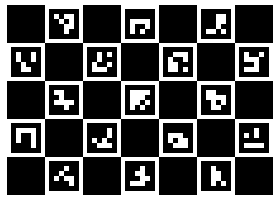

In [8]:
board = CharucoBoard(margin_size_m=0.005)
print(board)
media.show_image(board.image())

## Create data folder

Create the folder used to save images, intrinsics, and extrinsic-calibration samples.


In [9]:
img_dir = "mujoco_charuco_calib"
path_img_dir = create_data_dir(img_dir)

[RBS_WARNING] [1779327090.476059437] [robotblockset.cameras.collect_calibration_data]: The data subfolder of mujoco_charuco_calib already exists and is not empty.


## Move camera and set object frame

Place the robot-mounted plate in front of the camera and set the object frame to match the camera frame.


In [10]:
r.SetMocapPose('cam_cam',[1.7, 0, 0.4])
r.Wait(0.5)
pcam = r.GetObjectPose('site','cam_frame')
r.SetObject(pcam)

In [11]:
r.TObject

array([[ 0. , -0. , -1. ,  1.7],
       [ 1. ,  0. , -0. ,  0. ],
       [ 0. , -1. ,  0. ,  0.4],
       [ 0. ,  0. ,  0. ,  1. ]])

In [12]:
pl = r.GetObjectPose('site','plate_charuco_origin')
print(r.WorldToObject(pl))

[-0.1    0.182  1.386  0.707  0.003  0.003 -0.707]


In [13]:
r.SetMocapPose("Target", pl)

In [14]:
r.TCP

array([[-0.   ,  0.707,  0.707,  0.   ],
       [ 0.   ,  0.707, -0.707,  0.   ],
       [-1.   , -0.   , -0.   ,  0.228],
       [ 0.   ,  0.   ,  0.   ,  1.   ]])

# Preliminary checks

Before collecting calibration data, verify that the board is visible, the detector works, and the estimated board frame is drawn correctly in the image.


## Move to pose and check board detection


In [15]:
r.CMoveFor([0.1, 0, 0])

0

In [16]:
r.CMoveFor(rot_z(-np.pi / 8))

0

## Check board frame detection

Capture one image and convert it to OpenCV format for Charuco detection.


""

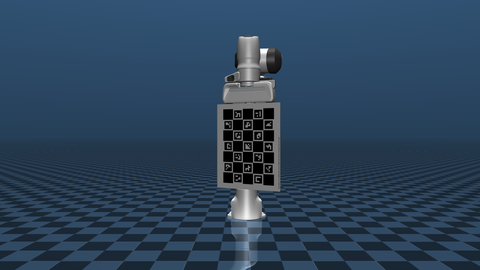

In [17]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
media.show_image(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Detect the board and visualize all detected markers and Charuco corners.


""

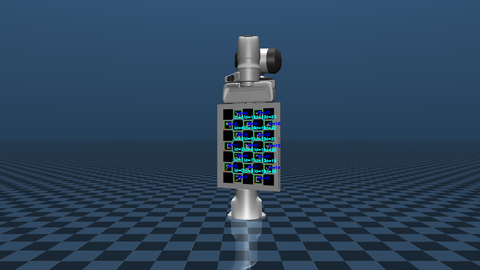

In [18]:
det = board.detect(gray)
img_det = board.drawDetection(image_bgr.copy(), det)
media.show_image(cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Estimate the board pose in the camera frame from the detected Charuco corners.


In [19]:
pose = board.detectPose(gray, camera.intrinsics_matrix(), None)
pose.as_pose()

array([-0.073,  0.179,  1.331,  0.695, -0.128,  0.138, -0.694])

""

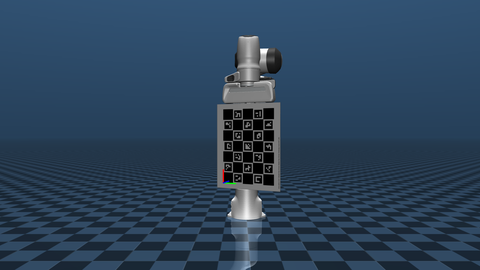

In [20]:
img = board.drawFrame(image_bgr, pose, camera.intrinsics_matrix(), None, length=0.05)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

## Test module functions


In [21]:
image_bgr = image_rgb.copy()

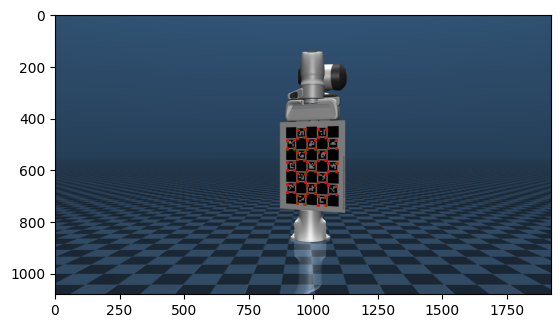

In [22]:
res1 = detect_aruco_markers(image_bgr, board.dictionary)
res2 = detect_charuco_corners(image_bgr, res1, board.board)
res0 = BoardDetectionResults(*board.detector.detectBoard(image_bgr))
fig, axes = plt.subplots(1, 1)
axes.imshow(image_bgr)
axes.scatter(
    np.array(res1.corners).squeeze().reshape(-1, 2)[:, 0],
    np.array(res1.corners).squeeze().reshape(-1, 2)[:, 1],
    s=5,
    c="green",
    marker=".",
)
axes.scatter(
    np.array(res0.aruco_corners).squeeze().reshape(-1, 2)[:, 0],
    np.array(res0.aruco_corners).squeeze().reshape(-1, 2)[:, 1],
    s=5,
    c="red",
    marker=".",
)


In [23]:
detected_pose = get_pose_of_charuco_board(res2, board.board, camera_matrix=intrinsics)
print("Detected pose:\n", detected_pose)

Detected pose:
 [[-0.001  0.93   0.368 -0.073]
 [-1.     0.005 -0.014  0.179]
 [-0.015 -0.368  0.93   1.331]
 [ 0.     0.     0.     1.   ]]


""

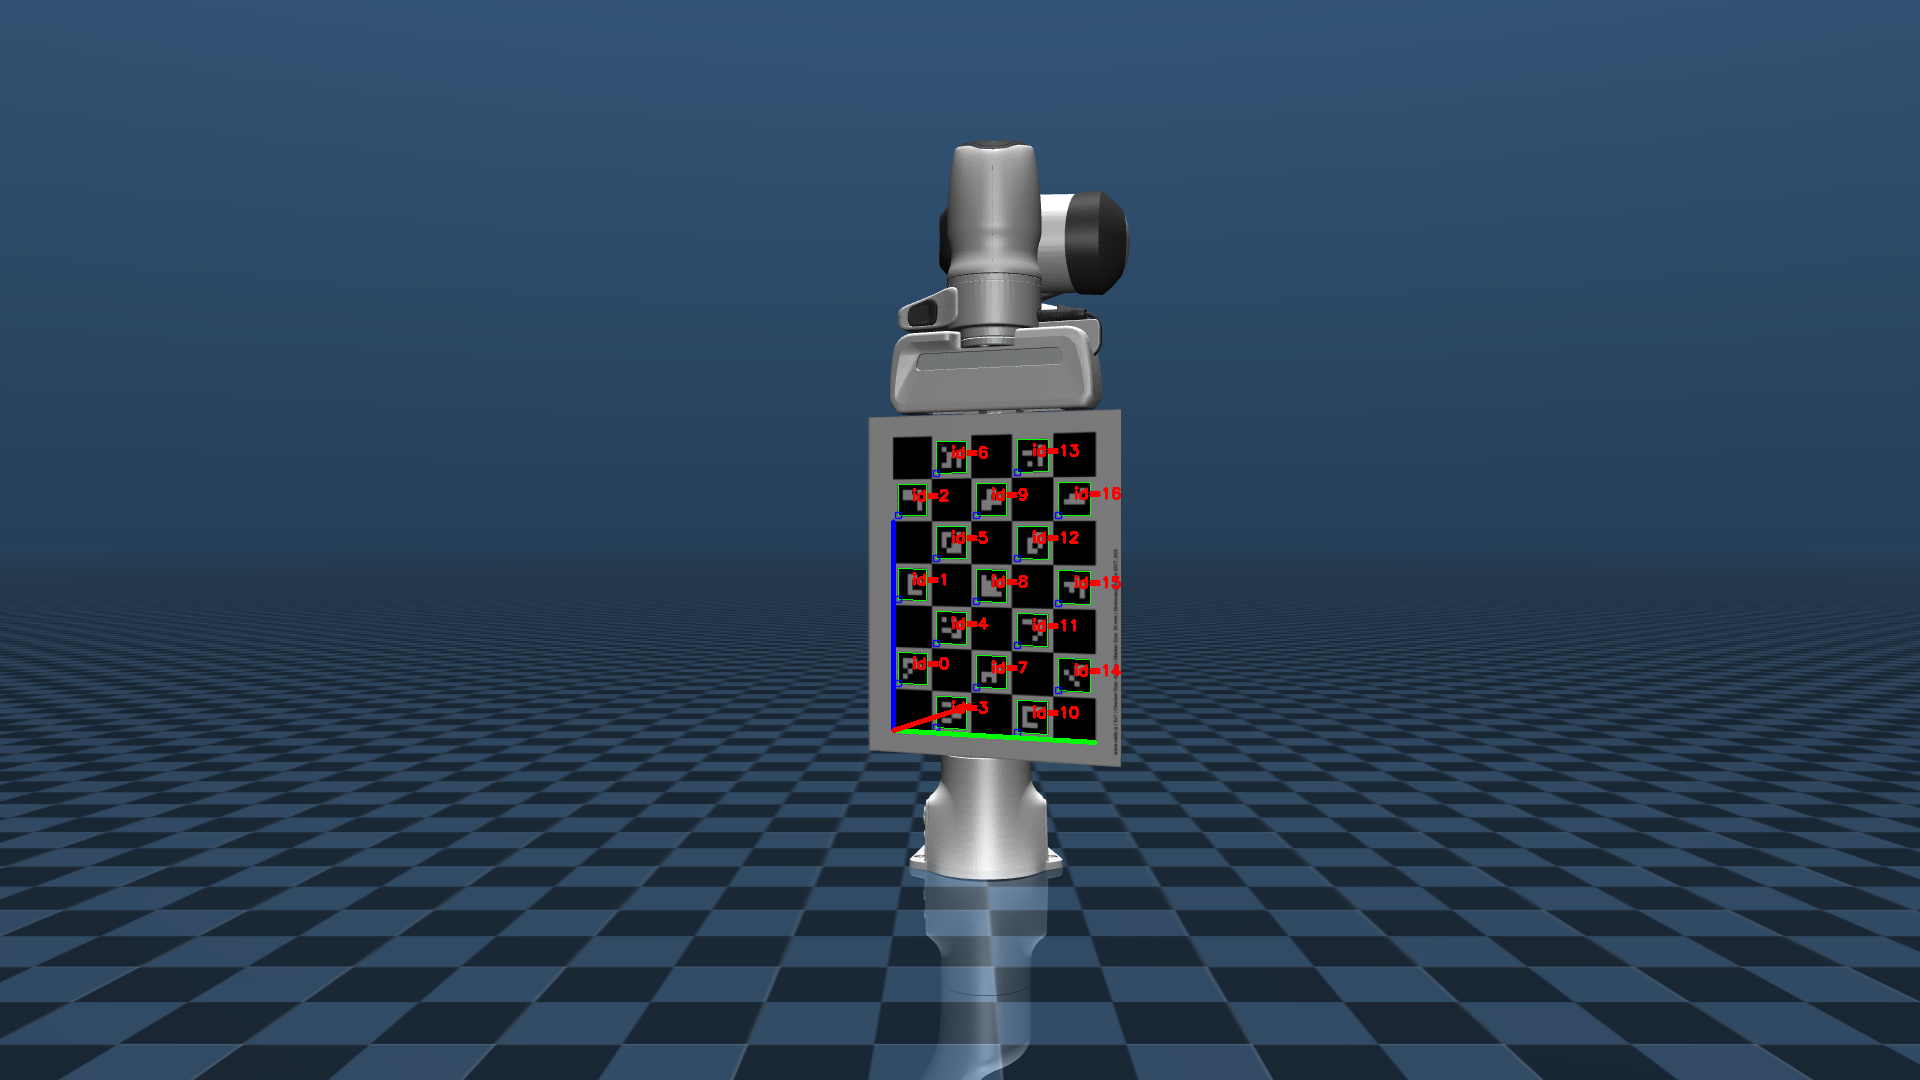

In [24]:
detected_pose = detect_and_visualize_charuco_pose(image_bgr, camera.intrinsics_matrix(), board.dictionary, board.board, draw_aruco_detection=True, draw_charuco_detection=False)
media.show_image(image_bgr)


# Intrinsic calibration

Intrinsic calibration estimates the focal lengths, principal point, and distortion parameters from multiple images of the Charuco board observed from varied poses.


## Motion generation


Select a nominal pose where the plate is centered in the camera view and approximately facing the camera.

Move the robot to this pose before generating random calibration views.


In [25]:
x0 = np.array([0.4, -0.   ,  0.5 ,  0, -0.71 , 0,  -0.704])
r.JMove(r.q_home)
r.CMove(x0)
q0 = r.q_ref
r.JMove(q0)

0

Execute a test motion and capture a set of varied board views for intrinsic calibration.


In [26]:
images=[]
it=0
for i in range(12):
    # xx = map_pose(p=x0[:3] + np.random.randn(3) * [0.1, 0.2, 0.05], RPY=map_pose(Q=x0[3:], out="RPY") + np.random.randn(3) * 0.4)
    r.JMove(q0)
    r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
    r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.9, np.random.uniform(-1, 1) * 0.3, np.random.uniform(-1, 1) * 0.9], out="Q"))
    r.Wait(0.2)
    image_rgb = camera.get_rgb_image_as_int()
    image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
    images.append(image_bgr)

Save images.


In [27]:
save_images(img_dir, images)

## Load captured images


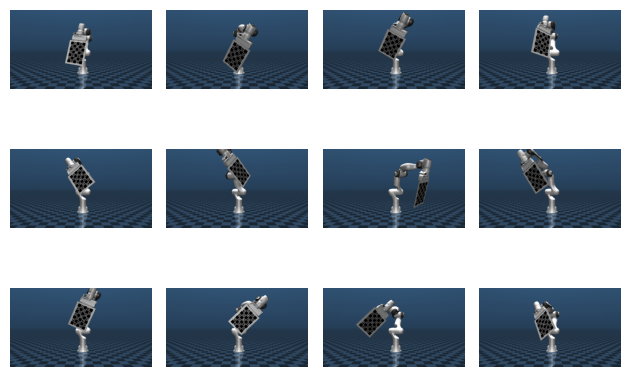

In [28]:
images = load_images(img_dir)
display_images(images, bgr2rgb=True)

Show the captured calibration images.


## Calculate intrinsics

Solve for the camera intrinsics from the collected calibration images.


In [29]:
calib_res = board.intrinsic_calibration(images, silent=True)
print("Matrix:\n", calib_res.to_camera_intrinsics().as_matrix())

Matrix:
 [[1381.532    0.     953.556]
 [   0.    1381.408  559.377]
 [   0.       0.       1.   ]]


Save the calibrated intrinsics to a JSON file.


In [30]:
calib_res.write_intrinsics_json("mujoco",camera.name, out_dir=img_dir)

WindowsPath('mujoco_charuco_calib/mujoco_cam_RGB_intrinsic_calibration.json')

Set the calibrated camera intrinsics.


In [31]:
camera._intrinsics_matrix = calib_res.to_camera_intrinsics().as_matrix()

# Extrinsic calibration

Extrinsic calibration estimates the rigid transform between the robot base and the camera. Each sample must contain an image together with the corresponding robot TCP pose and the simulated ground-truth poses available in MuJoCo.


## Prepare data folder

Create the directory structure expected by the extrinsic-calibration utilities.


In [32]:
data_dir = prepare_collect_calibration_data(camera, img_dir)

[RBS_WARNING] [1779327125.466411829] [robotblockset.cameras.collect_calibration_data]: The data subfolder of mujoco_charuco_calib already exists and is not empty.
[RBS_INFO] [1779327125.467412710] [robotblockset.cameras.collect_calibration_data]: Saving calibration data to mujoco_charuco_calib\data


## Move to initial pose

Return to the nominal pose before sampling random extrinsic-calibration views.


In [33]:
x0 = np.array([0.4, -0.   ,  0.5 ,  0, -0.71 , 0,  -0.704])
r.JMove(r.q_home)
r.CMove(x0)
q0 = r.q_ref
r.JMove(q0)

0

## Capture and save random poses and images

Save image-and-pose samples for extrinsic calibration.


In [34]:
for sample_index in range(20):
    r.JMove(q0)
    r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
    r.CMoveFor(map_pose(RPY=[np.random.uniform(-1, 1) * 0.9, np.random.uniform(-1, 1) * 0.3, np.random.uniform(-1, 1) * 0.9], out="Q"))
    tcp_pose, board_pose, camera_pose, joint_pos, image_bgr = mujoco_save_calibration_sample(sample_index, r, camera, data_dir)  # type: ignore
    print(f"Saved {sample_index+1} sample(s).")

Saved 1 sample(s).
Saved 2 sample(s).
Saved 3 sample(s).
Saved 4 sample(s).
Saved 5 sample(s).
Saved 6 sample(s).
Saved 7 sample(s).
Saved 8 sample(s).
Saved 9 sample(s).
Saved 10 sample(s).
Saved 11 sample(s).
Saved 12 sample(s).
Saved 13 sample(s).
Saved 14 sample(s).
Saved 15 sample(s).
Saved 16 sample(s).
Saved 17 sample(s).
Saved 18 sample(s).
Saved 19 sample(s).
Saved 20 sample(s).


## Load captured images

Load the saved images together with the corresponding robot, board, and camera poses.


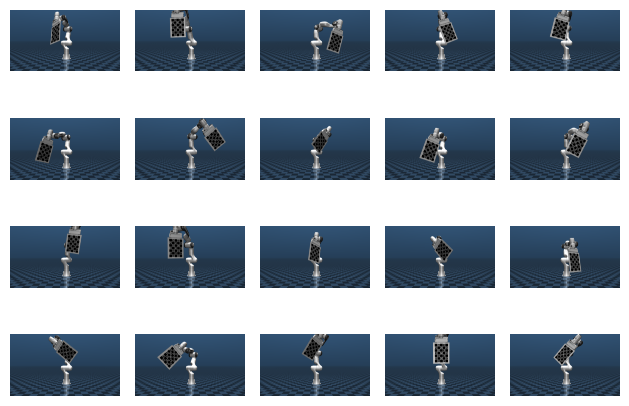

In [35]:
images, tcp_poses, board_poses, camera_poses, joint_poses, intrinsics, resolution = mujoco_load_calibration_data(data_dir)
display_images(images, bgr2rgb=True)

## Check board detection


Select one captured pose.


In [36]:
ii = 8
actual_board_T = board_poses[ii]
img = images[ii]
cam_T = camera_poses[ii]
qq = joint_poses[ii]


Move to the selected configuration.


In [37]:
_ = r.JMove(qq)
r.SetMocapPose("Target", actual_board_T)

Check board detection.

Compare the detected board pose with the simulated ground-truth pose for one sample.


Detected board pose in camera frame:  [-0.273  0.105  1.189  0.798  0.077 -0.199 -0.564]
Actual   board pose in camera frame:  [-0.312  0.122  1.191 -0.797 -0.077  0.206  0.562]


""

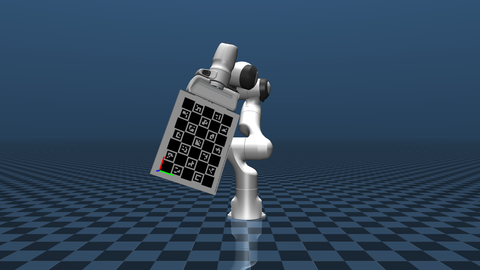

In [38]:
detected_pose = board.detectPose(img, camera.intrinsics_matrix(), None).as_pose()
print("Detected board pose in camera frame: ", detected_pose)
actual_board_pose = uniqueCartesianPath(t2x(actual_board_T))
print("Actual   board pose in camera frame: ", world2frame(actual_board_pose,cam_T))
img_vis = board.drawFrame(img, detected_pose, camera.intrinsics_matrix(), None, length=0.05)
media.show_image(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

## Check board detection for all captured poses


The position error is caused by the offset between the camera center and the MuJoCo `RGBCamera` body location.

Run the detector on all saved images and inspect pose errors across the dataset.


 19:  Board pos in camera frame: [-0.209 -0.133  1.392  0.884 -0.208  0.151 -0.391]  detected: [-0.17  -0.153  1.389  0.886 -0.201  0.154 -0.39 ]  error: [-0.039  0.02   0.002 -0.016  0.002 -0.001]
 18:  Board pos in camera frame: [-0.111 -0.039  1.211  0.703  0.031  0.009 -0.71 ]  detected: [-0.072 -0.056  1.204  0.704  0.02   0.007 -0.71 ]  error: [-0.039  0.017  0.007  0.019 -0.013 -0.001]
 17:  Board pos in camera frame: [-0.221 -0.186  1.303  0.829  0.27  -0.152 -0.466]  detected: [-0.182 -0.206  1.306  0.829  0.271 -0.144 -0.468]  error: [-0.039  0.019 -0.003 -0.01  -0.013 -0.002]
 16:  Board pos in camera frame: [-0.467 -0.105  1.133  0.877  0.05  -0.309 -0.364]  detected: [-0.429 -0.121  1.13   0.878  0.053 -0.304 -0.366]  error: [-0.038  0.016  0.003 -0.01  -0.008 -0.   ]
 15:  Board pos in camera frame: [ 0.044 -0.052  1.348  0.319 -0.164  0.17  -0.918]  detected: [ 0.082 -0.072  1.346  0.32  -0.164  0.175 -0.917]  error: [-0.038  0.02   0.002 -0.011 -0.002 -0.001]
 14:  Boar

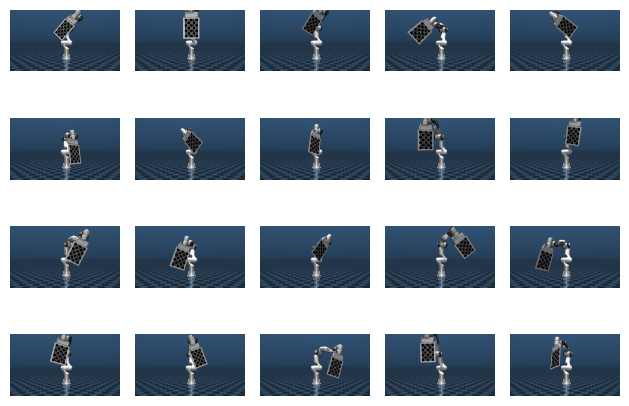

In [39]:
board_images = []
detected_poses = []
for ii in reversed(range(len(images))):
    img = images[ii].copy()
    detected_pose = board.detectPose(img, camera.intrinsics_matrix(), None).as_pose()
    if detected_pose is None:
        images.pop(ii)
        tcp_poses.pop(ii)
        board_poses.pop(ii)
        camera_poses.pop(ii)
    else:
        board_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        actual_board_pose = uniqueCartesianPath(t2x(r.WorldToObject(board_poses[ii])))
        print(f"{ii:3d}:  Board pos in camera frame: {actual_board_pose}  detected: {detected_pose}  error: {xerr(actual_board_pose, detected_pose)}")
        # actual_board_pose = world2frame(board_poses[ii], camera_poses[ii])
        # print(f"{ii}:  Board pos in camera frame: {t2x(board_pose_in_camera_frame)}  detected: {t2x(detected_pose)}")
        detected_poses.append(detected_pose)
display_images(board_images)

## Eye-to-hand calibration


In [40]:
results_dir = os.path.join(img_dir, f"results")
os.makedirs(results_dir, exist_ok=True)
print(results_dir)

mujoco_charuco_calib\results


In [41]:

images, tcp_poses, intrinsics, resolution = load_calibration_data(img_dir)


Solve the eye-to-hand calibration with several methods and keep the lowest-error result.


In [42]:
poses_dict, errors_dict = extrinsic_calibration_all_methods(results_dir, images, tcp_poses, intrinsics, mode="eye_to_hand")
min_error_key = min(errors_dict, key=lambda x: errors_dict.get(x) or float("inf"))
camera_pose_best = poses_dict[min_error_key]


[RBS_INFO] [1779327188.578671694] [robotblockset.cameras.camera_calibration]: Board poses were detected in 20 of the calibration samples.
[RBS_INFO] [1779327188.910325527] [robotblockset.cameras.camera_calibration]: Residual error Tsai: 0.0272
[RBS_INFO] [1779327188.960387230] [robotblockset.cameras.camera_calibration]: Residual error Park: 0.0265
[RBS_INFO] [1779327188.992906332] [robotblockset.cameras.camera_calibration]: Residual error Haraud: 0.0265
[RBS_INFO] [1779327189.028706551] [robotblockset.cameras.camera_calibration]: Residual error Andreff: 0.0396
[RBS_INFO] [1779327189.039706230] [robotblockset.cameras.camera_calibration]: Residual error Daniilidis: 0.0256


Compare the ground-truth and detected camera poses in the robot frame.


In [43]:
print("Actual camera pose:\n", camera_offset @ x2t(uniqueCartesianPath(r.GetObjectPose("site",'cam_frame'))))
print("Detected camera pose:\n", camera_pose_best)

Actual camera pose:
 [[ 0.    -0.    -1.     1.702]
 [ 1.     0.    -0.    -0.032]
 [ 0.    -1.     0.     0.4  ]
 [ 0.     0.     0.     1.   ]]
Detected camera pose:
 [[-0.006  0.008 -1.     1.695]
 [ 1.    -0.001 -0.006 -0.031]
 [-0.001 -1.    -0.008  0.391]
 [ 0.     0.     0.     1.   ]]


### Draw the robot frame in one image


Inspect the estimated camera position in the robot frame.


In [44]:
robot_base_in_camera_frame = np.linalg.inv(camera_pose_best)

Select an image and draw the robot frame in it.


""

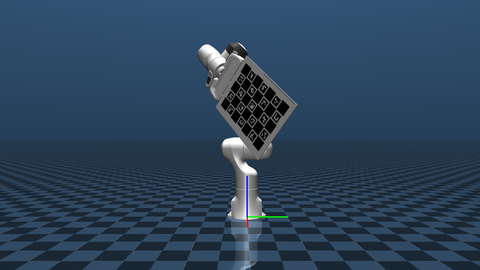

In [45]:
ii = 13
img = images[ii]
img_vis = board.drawFrame(img, robot_base_in_camera_frame, camera.intrinsics_matrix(), None, length=0.2)
media.show_image(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

# Useful relations

After calibration, camera-frame detections can be transformed into the robot frame. The following examples show how to use the estimated camera pose to localize the board and individual ArUco markers.


## Camera position in robot frame

Use the best estimated camera pose from the extrinsic-calibration step.


In [46]:
camera_pose = camera_pose_best
print("Final camera pose:\n", camera_pose)

Final camera pose:
 [[-0.006  0.008 -1.     1.695]
 [ 1.    -0.001 -0.006 -0.031]
 [-0.001 -1.    -0.008  0.391]
 [ 0.     0.     0.     1.   ]]


Move the robot to a selected configuration.


In [ ]:
r.JMove(q0)
r.CMoveFor([0.1, 0, 0])
r.CMoveFor(np.random.randn(3) * [0.05, 0.2, 0.1])
r.CMoveFor(map_pose(RPY=[np.random.randn(1) * 0.7, np.random.randn(1) * 0.3, np.random.randn(1) * 0.7], out="Q"))
r.Wait(0.2)

0

Detect the board in the current image and recover its pose in the camera frame.


""

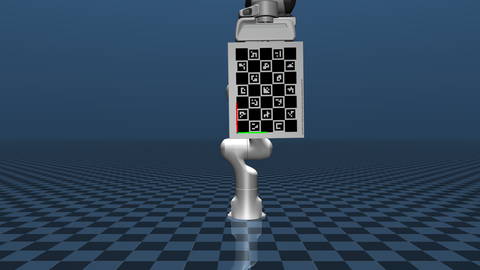

In [59]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format
board_T = board.detectPose(image_bgr, intrinsics).as_homogeneous_matrix()
img = board.drawFrame(image_bgr,board_T, intrinsics)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 4, height=camera.resolution[1] // 4)

Compute the board position in the robot frame.


In [60]:
board_T_robot = frame2world(board_T, camera_pose)
print("Detected board pose in robot frame: ", t2x(board_T_robot))

actual_board_pose = uniqueCartesianPath(r.GetObjectPose("site",'plate_charuco_origin'))
print("Actual   board pose in robot frame: ", actual_board_pose)

Detected board pose in robot frame:  [ 0.544 -0.043  0.406  0.709  0.006 -0.705 -0.004]
Actual   board pose in robot frame:  [ 0.543 -0.043  0.407  0.717  0.009 -0.697 -0.003]


In [62]:
r.SetMocapPose("Target", board_T_robot)

## Position of ArUco and Charuco markers in robot frame


Capture an image.


In [63]:
image_rgb = camera.get_rgb_image_as_int()
image_bgr = ImageConverter.from_numpy_int_format(image_rgb).image_in_opencv_format


Detect ArUco and Charuco markers.


""

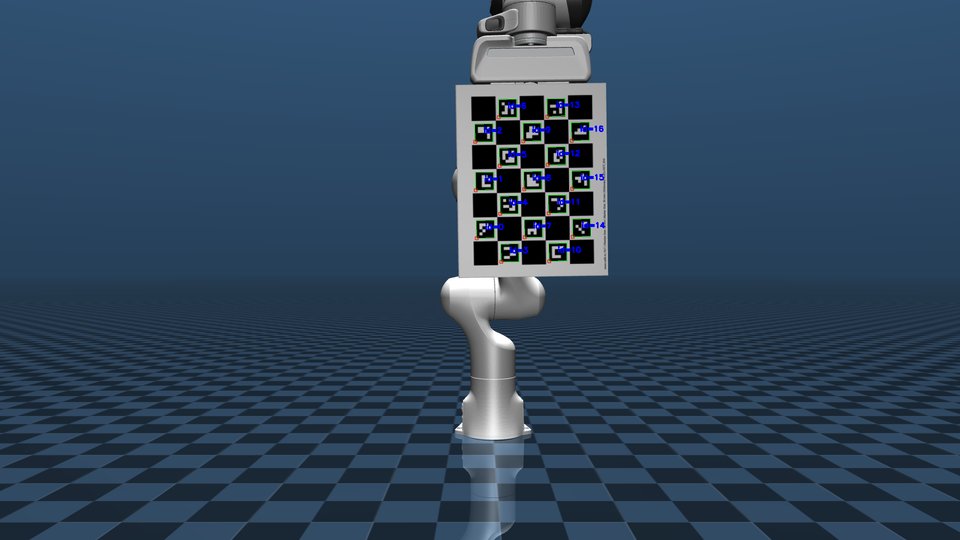

In [64]:
det_result = board.detect(image_bgr)

img = board.drawDetection(image_bgr,det_result, draw_charuco=False)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)


""

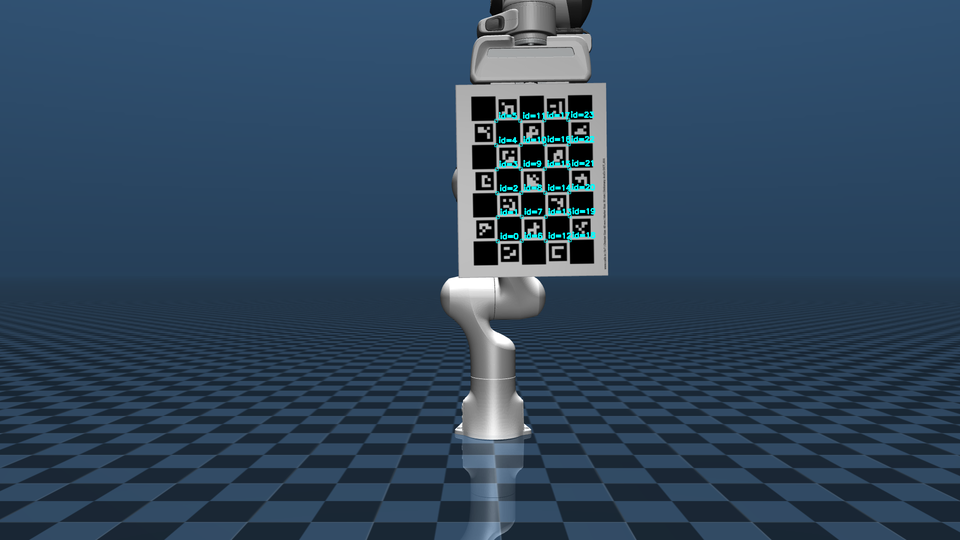

In [65]:
img = board.drawDetection(image_bgr,det_result, draw_aruco=False)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)

List all marker positions in the robot frame.

Convert all detected marker poses from the camera frame into the robot frame.


In [66]:
marker_poses_in_camera_frame = board.get_poses_of_aruco_markers(det_result, intrinsics)
marker_poses_in_robot_frame = frame2world(marker_poses_in_camera_frame, camera_pose)
for i, pose in enumerate(marker_poses_in_robot_frame):
    print(f"Aruco marker ID {int(det_result.aruco_ids[i][0]):2d}:   Pose in robot frame: {t2x(pose)}")

# t2x(marker_poses_in_camera_frame)

Aruco marker ID  8:   Pose in robot frame: [ 0.487  0.059  0.556  0.089  0.79  -0.097  0.599]
Aruco marker ID  5:   Pose in robot frame: [ 0.487  0.016  0.597  0.004 -0.836  0.015 -0.548]
Aruco marker ID 11:   Pose in robot frame: [ 0.49   0.101  0.514  0.047 -0.697 -0.03  -0.715]
Aruco marker ID 16:   Pose in robot frame: [ 0.485  0.142  0.641  0.094  0.805 -0.104  0.576]
Aruco marker ID  4:   Pose in robot frame: [ 0.488  0.018  0.513  0.003  0.698 -0.011  0.716]
Aruco marker ID  1:   Pose in robot frame: [ 0.489 -0.025  0.554  0.012 -0.699 -0.003 -0.715]
Aruco marker ID 15:   Pose in robot frame: [ 0.488  0.143  0.556  0.1    0.791 -0.109  0.594]
Aruco marker ID  2:   Pose in robot frame: [ 0.488 -0.026  0.639  0.004  0.838 -0.012  0.546]
Aruco marker ID  9:   Pose in robot frame: [ 0.488  0.058  0.64   0.009 -0.702  0.    -0.712]
Aruco marker ID  6:   Pose in robot frame: [ 0.487  0.015  0.681  0.004 -0.703  0.004 -0.712]
Aruco marker ID 13:   Pose in robot frame: [ 0.48   0.101  0

Select one marker and show its frame in the image.

Pick one marker, visualize its camera-frame pose in the image, and compare it in the robot frame.


""

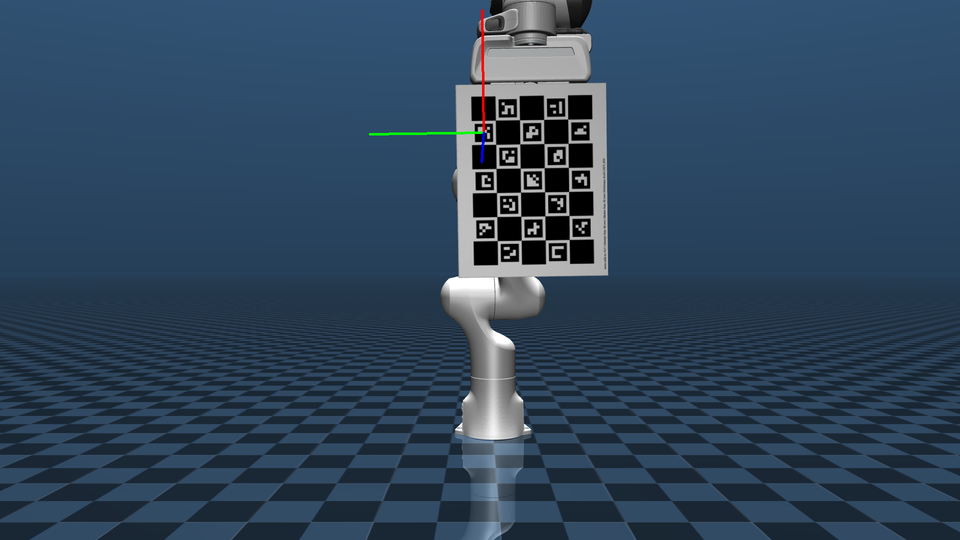

In [67]:
marker_cam = marker_poses_in_camera_frame[7]
marker_rob = marker_poses_in_robot_frame[7]
img = board.drawFrame(image_bgr, marker_cam, intrinsics, length=0.2)
media.show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), width=camera.resolution[0] // 2, height=camera.resolution[1] // 2)

Check the detected marker pose on the robot.


In [68]:
r.SetMocapPose("Target", marker_rob)